<a href="https://colab.research.google.com/github/NganNguyenKha/DN-group-CMPE-132/blob/CNN/CNN_Wednesday_AMPM_DOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #!/usr/bin/env python
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sklearn.preprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
import missingno

In [ ]:
train_data = pd.read_csv('/content/Wednesday-workingHours.pcap_ISCX.csv.train.csv')
test_data = pd.read_csv('/content/Wednesday-workingHours.pcap_ISCX.csv.test.csv')

In [ ]:
train_data_df = pd.DataFrame(train_data)
print(train_data_df.shape)

(554161, 79)


In [ ]:
#train_data_df = train_data_df[['Duration','protocol_type', 'Service', 'Srv serror rate', 'Flag','src_bytes','dst_bytes', 'Dst host serror rate', 'Dst host srv serror rate', 'Dst host same src port rate', 'Label','Serror rate','Count','Dst host count']]
train_data_df = train_data_df[[' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets', ' Label']]

In [ ]:
train_data_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets
count,554161.000000,5.541610e+05,554161.000000,5.541610e+05
mean,4353.489139,3.440277e+07,11.231243,6.478595e+02
std,13917.551126,4.525126e+07,835.121576,6.796262e+03
min,0.000000,-1.000000e+00,1.000000,0.000000e+00
25%,80.000000,5.120000e+02,2.000000,1.200000e+01
50%,80.000000,2.234160e+05,3.000000,1.290000e+02
75%,443.000000,8.540103e+07,7.000000,3.770000e+02
max,65418.000000,1.200000e+08,203943.000000,1.224076e+06


In [ ]:
train_data_df = train_data_df.dropna()

In [ ]:
print(train_data_df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       'Total Length of Fwd Packets', ' Label'],
      dtype='object')


# Feature Engineering

# New Section

# New Section

In [ ]:
def encodify(dataframe, feature):
    encoder = LabelEncoder()
    encoder.fit(dataframe[feature])
    encoded_feature = encoder.transform(dataframe[feature])
    dataframe[feature] = encoded_feature

In [ ]:
discrete_feature_l = [' Destination Port', ' Flow Duration', ' Total Fwd Packets']
for feature in discrete_feature_l:
    encodify(train_data_df, feature)

# train-to-test split

In [ ]:
eighty_cut_n = math.ceil(train_data_df.shape[0] * 0.8)
print(eighty_cut_n)

443329


In [ ]:
train_data_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Label
0,5,21742,0,6,BENIGN
1,12,480,10,172,BENIGN
2,6,1096,9,3150,BENIGN
3,12,10045,16,3452,BENIGN
4,6,1093,8,3150,BENIGN


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
Scaler = StandardScaler()

In [ ]:
X = train_data_df.loc[:, [' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets']]
y = train_data_df.loc[:, ' Label']

In [ ]:
X=Scaler.fit_transform(X)

In [ ]:
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_data.shape
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 420)

In [ ]:
X_train.shape


(1234648, 4)

In [ ]:
X_test.shape

(308662, 4)

In [ ]:
y_train.value_counts()

,count
Label,
DoS Hulk,247202
BENIGN,247112
DoS GoldenEye,246788
DoS Slowhttptest,246784
DoS slowloris,246762


<ipython-input-31-baa50a2511b9>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_train, sort = True)


Text(0, 0.5, 'Frequency')

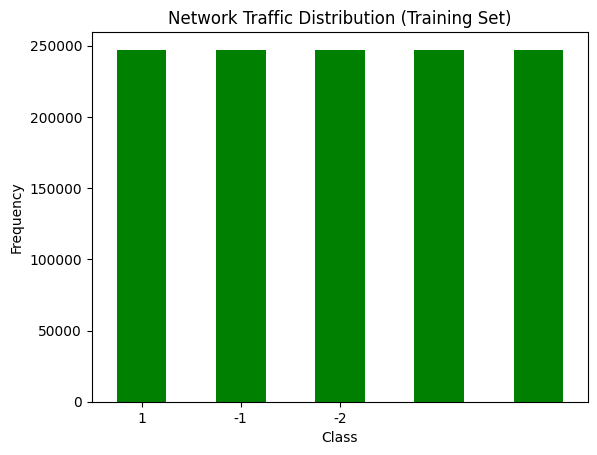

In [ ]:
label_l = ['1', '-1','-2']
classes = pd.value_counts(y_train, sort = True)
classes.plot(kind = 'bar', rot = 0, color = "green")
plt.title("Network Traffic Distribution (Training Set)")
plt.xticks(range(3), label_l)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [ ]:
y_test.value_counts()

,count
Label,
DoS slowloris,61900
DoS Slowhttptest,61878
DoS GoldenEye,61874
BENIGN,61550
DoS Hulk,61460


<ipython-input-33-2b5c4e26709d>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_test , sort = True)


Text(0, 0.5, 'Frequency')

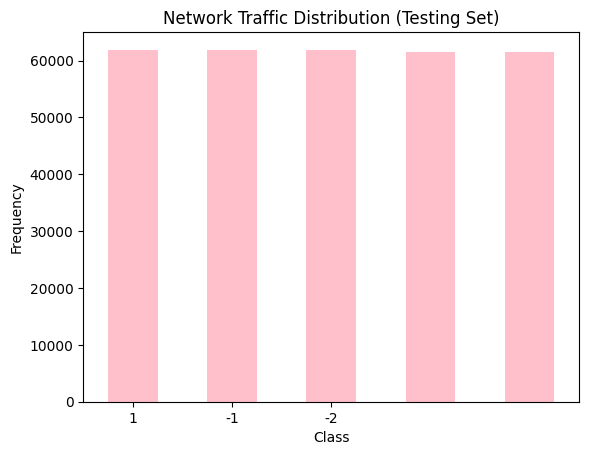

In [ ]:
labels = ['1', '-1','-2']
classes = pd.value_counts(y_test , sort = True)
classes.plot(kind = 'bar', rot = 0, color = "pink")
plt.title("Network Traffic Distribution (Testing Set)")
plt.xticks(range(3), labels)
plt.xlabel("Class")
plt.ylabel("Frequency")

## Modeling

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
clf = MLPClassifier(solver='adam', alpha=1e-5,

                    hidden_layer_sizes=(5, 2), random_state=1, max_iter=1000)

In [ ]:
clf.fit(X, y)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), max_iter=1000,
              random_state=1)

In [ ]:
pred_test_y = clf.predict(X_test)
print(pred_test_y)

['BENIGN' 'BENIGN' 'DoS Hulk' ... 'DoS slowloris' 'BENIGN' 'BENIGN']


In [ ]:
accuracy_score(y_test, pred_test_y)

0.756788979531008

In [ ]:
cm = confusion_matrix(y_test, pred_test_y)

In [ ]:
# Calculate overall accuracy
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall accuracy is {overall_accuracy}")

# Calculate per-class metrics
num_classes = cm.shape[0]
for i in range(num_classes):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    tn = np.sum(cm) - tp - fp - fn

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0  # Handle zero division
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0  # Handle zero division

    print(f"Metrics for class {i}:")
    print(f"  Accuracy: {accuracy}")
    print(f"  Precision: {precision}")
    print(f"  Recall: {recall}")

Overall accuracy is 0.756788979531008
Metrics for class 0:
  Accuracy: 0.8421120837680052
  Precision: 0.5736382440818203
  Recall: 0.8110154346060113
Metrics for class 1:
  Accuracy: 0.9699995464294277
  Precision: 0.8918230563002681
  Recall: 0.9677247309047419
Metrics for class 2:
  Accuracy: 0.9011572529174308
  Precision: 0.9242769019876628
  Recall: 0.5485356329319883
Metrics for class 3:
  Accuracy: 0.9113107541582702
  Precision: 0.8787625968779502
  Recall: 0.6468373250589871
Metrics for class 4:
  Accuracy: 0.8889983217888824
  Precision: 0.6906594922737307
  Recall: 0.8087075928917609


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## SVM

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [ ]:
nslkdd_svm_clf = svm.SVC(kernel = 'poly').fit(X_train, y_train)

In [ ]:
pred_test_y = nslkdd_svm_clf.predict(X_test)
print(pred_test_y)

In [ ]:
accuracy_score(y_test, pred_test_y)

In [ ]:
confusion_matrix(y_test, pred_test_y)

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, pred_test_y).ravel()
print(f"accuracy is {(tp +tn)/(tn+fp+fn+tp)}")
print(f"precision is {tp / (tp + fp)}")
print(f"recall is {tp / (tp + fn)}")

In [ ]:
f1_score(y_test, pred_test_y, average='macro')